In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#import libraries for KNN
from sklearn.neighbors import KNeighborsClassifier

In [3]:
from sklearn.metrics import accuracy_score

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
#Generate dataset
np.random.seed(42)
values = np.random.rand(100)

In [6]:
print(values)

[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258 0.02058449 0.96990985
 0.83244264 0.21233911 0.18182497 0.18340451 0.30424224 0.52475643
 0.43194502 0.29122914 0.61185289 0.13949386 0.29214465 0.36636184
 0.45606998 0.78517596 0.19967378 0.51423444 0.59241457 0.04645041
 0.60754485 0.17052412 0.06505159 0.94888554 0.96563203 0.80839735
 0.30461377 0.09767211 0.68423303 0.44015249 0.12203823 0.49517691
 0.03438852 0.9093204  0.25877998 0.66252228 0.31171108 0.52006802
 0.54671028 0.18485446 0.96958463 0.77513282 0.93949894 0.89482735
 0.59789998 0.92187424 0.0884925  0.19598286 0.04522729 0.32533033
 0.38867729 0.27134903 0.82873751 0.35675333 0.28093451 0.54269608
 0.14092422 0.80219698 0.07455064 0.98688694 0.77224477 0.19871568
 0.00552212 0.81546143 0.70685734 0.72900717 0.77127035 0.07404465
 0.35846573 0.11586906 0.86310343 0.62329813 0.33089802 0.06355835
 0.31098232 0.32518332 0.72960618 0.63755747 0.88721274 0.4722

In [7]:
# Create labels for first 50 points
labels = []
for i in values[:50]:
    if i <= 0.5:
        labels.append('Class1')
    else:     
        labels.append('Class2')

In [8]:
# Remaining 50 are unlabeled
labels += [None] * 50
print(labels)

['Class1', 'Class2', 'Class2', 'Class2', 'Class1', 'Class1', 'Class1', 'Class2', 'Class2', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', 'Class1', 'Class1', 'Class1', 'Class2', 'Class1', 'Class1', 'Class2', 'Class1', 'Class1', 'Class1', 'Class1', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', 'Class2', 'Class1', 'Class1', 'Class2', 'Class2', 'Class2', 'Class1', 'Class1', 'Class2', 'Class1', 'Class1', 'Class1', 'Class1', 'Class2', 'Class1', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]


In [12]:
# Create DataFrame
data = {
    "Point": [f"x{i+1}" for i in range(100)],
    "Value": values,
    "Label": labels
}
df = pd.DataFrame(data)

In [13]:
# first 5 rows of dataframe
df.head()

,Point,Value,Label
0,x1,0.374540,Class1
1,x2,0.950714,Class2
2,x3,0.731994,Class2
3,x4,0.598658,Class2
4,x5,0.156019,Class1


In [15]:
# Split data
labelled_df = df[df["Label"].notna()]
unlabelled_df = df[df["Label"].isna()]

In [17]:
print(labelled_df.head()) 

  Point     Value   Label
0    x1  0.374540  Class1
1    x2  0.950714  Class2
2    x3  0.731994  Class2
3    x4  0.598658  Class2
4    x5  0.156019  Class1


In [19]:
unlabelled_df.head() #can use print or direct df.head()

,Point,Value,Label
50,x51,0.969585,None
51,x52,0.775133,None
52,x53,0.939499,None
53,x54,0.894827,None
54,x55,0.597900,None


In [20]:
X_train = labeled_df[["Value"]]
y_train = labeled_df["Label"]
X_test = unlabeled_df[["Value"]]

In [23]:
print(X_train.head())

      Value
0  0.374540
1  0.950714
2  0.731994
3  0.598658
4  0.156019


In [24]:
y_train.head()

0    Class1
1    Class2
2    Class2
3    Class2
4    Class1
Name: Label, dtype: object

In [25]:
# Generate true labels for testing
true_labels = ["Class1" if x <= 0.5 else "Class2" for x in values[50:]]

In [30]:
# Apply KNN for different k values
k_values = [1, 2, 3, 4, 5, 20, 30]
accuracies = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    predictions = knn.predict(X_test)
    
    # Accuracy
    accuracy = accuracy_score(true_labels, predictions) * 100
    accuracies[k] = accuracy
    
    print(f"Accuracy for k={k}: {accuracy:.2f}%")
    
    # Store predictions
    unlabeled_df[f"Label_k{k}"] = predictions

Accuracy for k=1: 100.00%
Accuracy for k=2: 100.00%
Accuracy for k=3: 98.00%
Accuracy for k=4: 98.00%
Accuracy for k=5: 98.00%
Accuracy for k=20: 98.00%
Accuracy for k=30: 100.00%


In [31]:
# Final result
df_result = unlabeled_df.drop(columns=["Label"])
print("\nFinal Predictions:")
print(df_result.head())

print("\nAccuracies:")
for k, acc in accuracies.items():
    print(f"k={k}: {acc:.2f}%")


Final Predictions:
   Point     Value Label_k1 Label_k2 Label_k3 Label_k4 Label_k5 Label_k20  \
50   x51  0.969585   Class2   Class2   Class2   Class2   Class2    Class2   
51   x52  0.775133   Class2   Class2   Class2   Class2   Class2    Class2   
52   x53  0.939499   Class2   Class2   Class2   Class2   Class2    Class2   
53   x54  0.894827   Class2   Class2   Class2   Class2   Class2    Class2   
54   x55  0.597900   Class2   Class2   Class2   Class2   Class2    Class2   

   Label_k30  
50    Class2  
51    Class2  
52    Class2  
53    Class2  
54    Class2  

Accuracies:
k=1: 100.00%
k=2: 100.00%
k=3: 98.00%
k=4: 98.00%
k=5: 98.00%
k=20: 98.00%
k=30: 100.00%


In [32]:
# Get numeric columns for Visualization
num_col = df.select_dtypes(include=['int', 'float']).columns

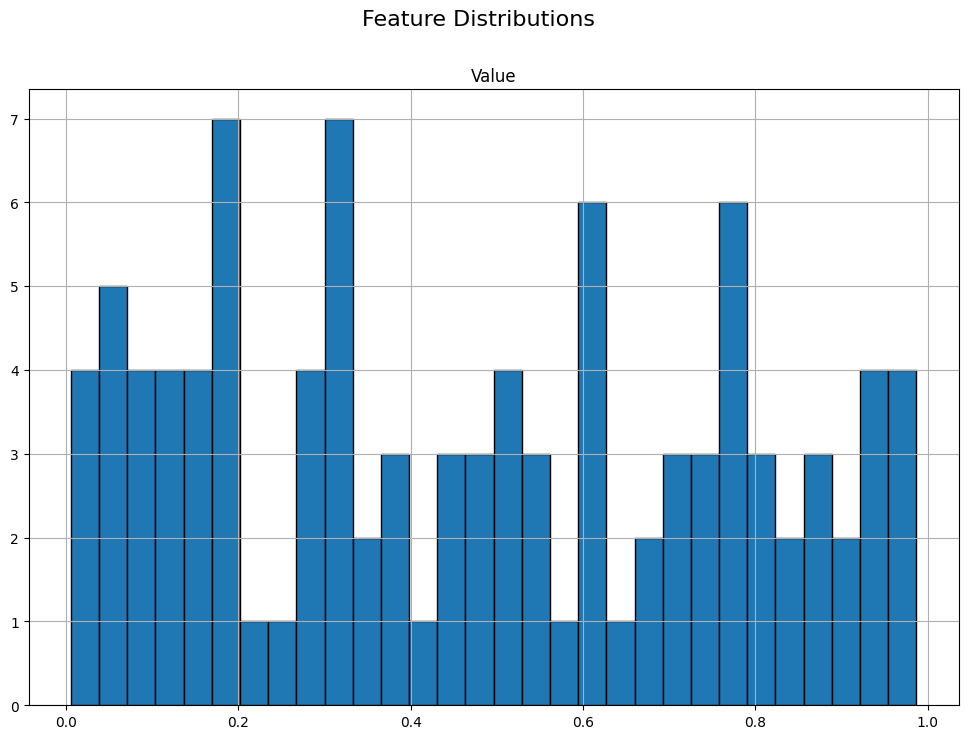

In [33]:
# Histograms for distribution of features
df[num_col].hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16) 
plt.show()